In [1]:
import numpy as np
import matplotlib.pyplot as plt

from alntk.alignment import Alignment, find_sequence

# Finding scaffolds for the sector library

*Written by Shoichi Yip. Last updated: 7 September 2026.*

In [2]:
aln = Alignment()
aln.import_from_fasta("../data/iter_aln_v2.faa")

In [3]:
thrombin_ss = find_sequence(aln, "Q19AZ8")
trypsin_rn = find_sequence(aln, "P00763")
trypsin_sg = find_sequence(aln, "P00775")
chymo_hr = find_sequence(aln, "P35003")
chymo_si = find_sequence(aln, "Q7SIG2")
chymo_bt = find_sequence(aln, "P00766")
elastase_ss = find_sequence(aln, "Q7SIG3")
elastase_mm = find_sequence(aln, "Q3UP87")
persephone_dm = find_sequence(aln, "Q9VWU1")
mcprotease_rn = find_sequence(aln, "P97594")
collagenase_hl = find_sequence(aln, "P08897")
granzyme_hs = find_sequence(aln, "P51124")
duodenase_bt = find_sequence(aln, "P80219")

In [4]:
scaffolds_seqs = np.array([
    thrombin_ss,
    trypsin_rn,
    trypsin_sg,
    chymo_hr,
    chymo_si,
    chymo_bt,
    elastase_ss,
    elastase_mm,
    persephone_dm,
    mcprotease_rn,
    collagenase_hl,
    granzyme_hs,
    duodenase_bt
])

scaffolds_labels = [
    "thrombin_ss",
    "trypsin_rn",
    "trypsin_sg",
    "chymo_hr",
    "chymo_si",
    "chymo_bt",
    "elastase_ss",
    "elastase_mm",
    "persephone_dm",
    "mcprotease_rn",
    "collagenase_hl",
    "granzyme_hs",
    "duodenase_bt"
]

In [5]:
def distance_matrix(aln):
    M, L = aln.shape
    dist = np.zeros((M, M), dtype=float)
    for i in range(M):
        mismatches = (aln[i] != aln).sum(axis=1)
        dist[i, :] = mismatches / L
    return dist

def plot_distance_matrix(dist, labels, figsize=(8, 6)):
    M = dist.shape[0]
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(dist, vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(np.arange(M))
    ax.set_yticks(np.arange(M))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Relative Hamming distance")
    ax.set_title("Pairwise Hamming distance heatmap")
    plt.tight_layout()
    plt.show()

## Check that global Hamming distance is far enough

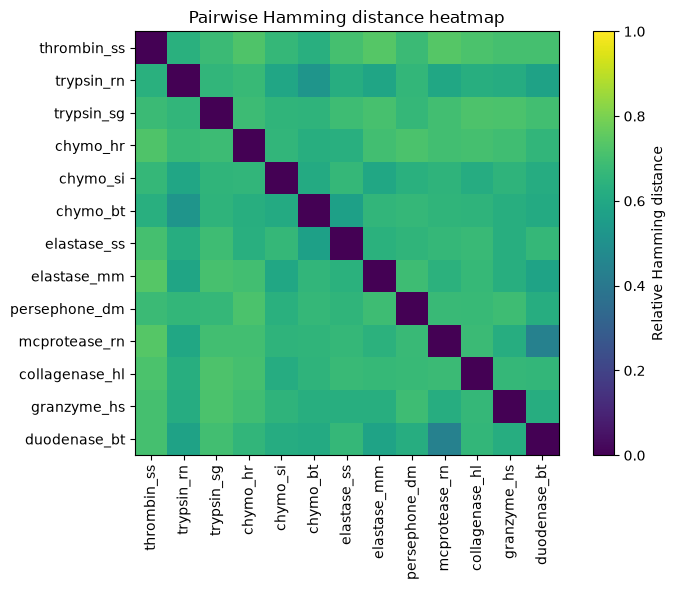

In [6]:
dist = distance_matrix(scaffolds_seqs)
plot_distance_matrix(dist, scaffolds_labels)

## Check that red sector Hamming distance is coherently clustered

In [7]:
red_sector = np.loadtxt("../data/iter_aln_v2_redsector.txt").astype(int)

In [8]:
scaffolds_seqs_red = scaffolds_seqs[:, red_sector]

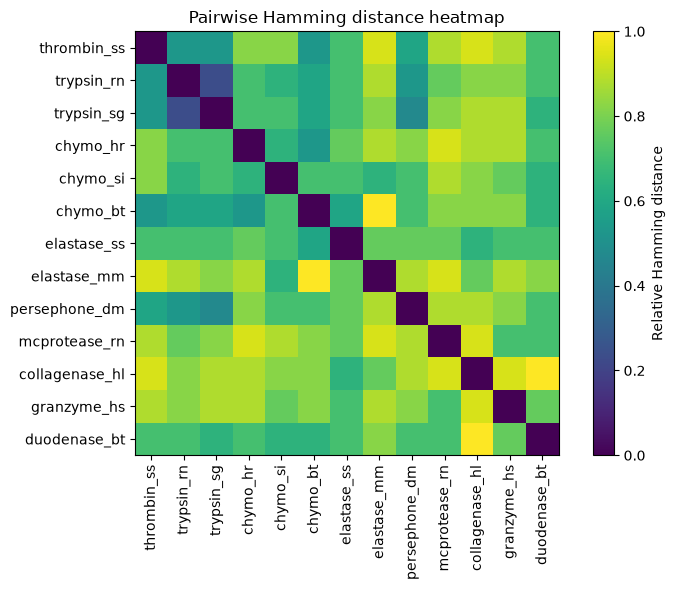

In [9]:
dist = distance_matrix(scaffolds_seqs_red)
plot_distance_matrix(dist, scaffolds_labels)

## Check anomalies in out of sector distance

In [10]:
L = scaffolds_seqs.shape[1]
non_red_sector = np.array(list(set(np.arange(L)) - set(red_sector)))

scaffolds_seqs_nonred = scaffolds_seqs[:, non_red_sector]

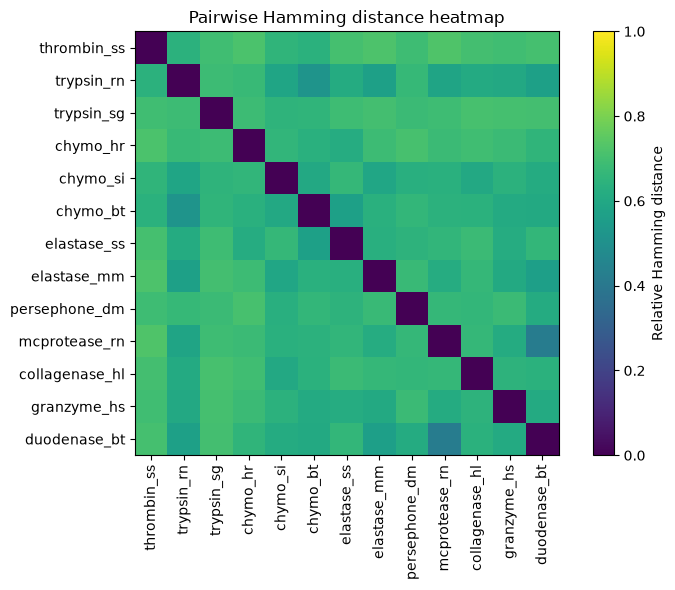

In [11]:
dist = distance_matrix(scaffolds_seqs_nonred)
plot_distance_matrix(dist, scaffolds_labels)

## Print the sequences and their red sectors

In [12]:
for l, s in zip(scaffolds_labels, scaffolds_seqs):
    print(f">{l}")
    print("".join(s).replace("-", ""))

>thrombin_ss
IVEGSDAEIGLAPWQVMIFRKSPQELLCGASLISDRWVLTAAHCLLYPPWTENDLLVRIGKHSRTRYERNIEKISMLEKIYIHPRYNWRENLDRDIALLKLRKPITFSDYIHPVCLPDKEATKLLRAGYKGRVTGWGNLKETWTSASEVQPSVLQVVNLPIVERLVCKASTRIRITDNMFCAGYKPDERGDACEGDSGGPFVMKSPNRWYQMGIVSWGEGCDRDGKYGFYTHVFRLKKWMQKVIDRF
>trypsin_rn
IVGGYTCQENSVPYQVSLNSGYHFCGGSLINDQWVVSAAHCYKSRIQVRLGEHNINVLEGNEQFVNAAKIIKHPNFDRKTLNNDIMLIKLSSPVKLNARVATVALPSSCAPAGTQCLISGWGNTLSSGVNEPDLLQCLDAPLLPQADCEASYPGKITDNMVCVGFLEGGKDSCQGDSGGPVVCNGELQGIVSWGYGCALPDNPGVYTKVCNYVDWIQDTIAAN
>trypsin_sg
VVGGTRAAQGEFPFMVRLSMGCGGALYAQDIVLTAAHCVSGSGNTSITATGGVVDLQSSSAVKVRSTKVLQAPGYNGTGKDWALIKLAQPINQPTLKIATTTAYNQGTFTVAGWGANREGGSQQRYLLKANVPFVSDAACRSAYGNELVANEEICAGYPDTGGVDTCQGDSGGPMFRKDNADEWIQVGIVSWGYGCARPGYPGVYTEVSTFASAI
>chymo_hr
IVGGSNAAAGEFPWQGSLQVRSGTSWFHICGCVLYTTSKALTAAHCLSNSASSYRLGFGMLRMNNVDGTEQYSSVTSYTNHPNYNGNAAGYPNDIAVLRLTSSMDTSSAVGPSVWLLVERLCRTNMYDQRMGKTQWRWQHPNNLQKVDMTVLTNSDCSSRWSGIGATVNSGHICIFESGRSACSGDSGGPLVCGNTLTGITSWGISSCSGSYPSVYTRVSSFYNWVQT
>chymo_si
IVGGKDAPVGKYPYQVSLRLSGSHRC

In [13]:
for l, s in zip(scaffolds_labels, scaffolds_seqs[:, red_sector]):
    print(f">{l}")
    print("".join(s))

>thrombin_ss
YDGWGEAMGLEFGDEDT
>trypsin_rn
YDGWGQVMGAGVGAGGY
>trypsin_sg
YDGWGQAEGVGVGAGTY
>chymo_hr
YSSWGSIHFMGVSS-RW
>chymo_si
YGDFGHTHLLGVPA-GQ
>chymo_bt
YSGWGMAMGLNVTS-VW
>elastase_ss
FSTFVNAMGLGVGN-NG
>elastase_mm
FGDFIFT-LVGAGGQRV
>persephone_dm
YDGSGKALILGLGAILY
>mcprotease_rn
FARYRKVQGLWV-TGES
>collagenase_hl
FSVFVFGTDNNGGE-GY
>granzyme_hs
AAPFSKLMALGVVTDKR
>duodenase_bt
YNDYGSAQGLGVNGRKF
